In [1]:
import os
import random
import time
from pathlib import Path
import numpy as np
from PIL import Image
import xml.etree.ElementTree as ET

import torch
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.transforms import v2 as T

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import warnings
warnings.filterwarnings('ignore')

from tqdm.auto import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

device: cuda


In [3]:
images_dir = "training_data/training_data/images"
labels_dir = "training_data/training_data/labels"

batch_size = 6
num_workers = 2
val_ratio = 0.15
epochs = 12

lr = 5e-3
weight_decay = 5e-4
momentum = 0.9

grad_clip = 5.0

In [4]:
def parse_xml_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    size = root.find("size")
    w_xml = float(size.find("width").text)
    h_xml = float(size.find("height").text)

    boxes = []
    for obj in root.findall("object"):
        name_node = obj.find("name")
        if name_node is not None and int(name_node.text) != 1:
            continue

        bndbox = obj.find("bndbox")
        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        xmin = max(0.0, min(xmin, w_xml - 1.0))
        xmax = max(0.0, min(xmax, w_xml - 1.0))
        ymin = max(0.0, min(ymin, h_xml - 1.0))
        ymax = max(0.0, min(ymax, h_xml - 1.0))

        x1, x2 = (xmin, xmax) if xmin <= xmax else (xmax, xmin)
        y1, y2 = (ymin, ymax) if ymin <= ymax else (ymax, ymin)

        if (x2 - x1) > 1e-3 and (y2 - y1) > 1e-3:
            boxes.append([x1, y1, x2, y2])

    return filename, np.array(boxes, dtype=np.float32), (int(w_xml), int(h_xml))


In [5]:
class CarsXmlDataset(Dataset):
    def __init__(self, images_dir, labels_dir, transforms=None, keep_empty=False):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.transforms = transforms

        self.items = []
        xmls = sorted([p for p in self.labels_dir.iterdir() if p.suffix.lower() == ".xml"])

        for xml_path in xmls:
            filename, boxes, _ = parse_xml_annotation(xml_path)
            img_path = self.images_dir / filename
            if not img_path.exists():
                continue
            if (boxes.shape[0] == 0) and (not keep_empty):
                continue
            self.items.append((img_path, xml_path))

        if len(self.items) == 0:
            raise RuntimeError("No (image, xml) pairs found. Check paths.")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, xml_path = self.items[idx]
        img = Image.open(img_path).convert("RGB")
        w_img, h_img = img.size

        filename, boxes, (w_xml, h_xml) = parse_xml_annotation(xml_path)

        if (w_xml != w_img) or (h_xml != h_img):
            if boxes.shape[0] > 0:
                sx = w_img / max(w_xml, 1)
                sy = h_img / max(h_xml, 1)
                boxes = boxes.copy()
                boxes[:, [0, 2]] *= sx
                boxes[:, [1, 3]] *= sy

        labels = np.ones((boxes.shape[0],), dtype=np.int64)

        target = {
            "boxes": torch.as_tensor(boxes, dtype=torch.float32),
            "labels": torch.as_tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([idx], dtype=torch.int64),
        }

        if target["boxes"].numel() > 0:
            area = (target["boxes"][:, 2] - target["boxes"][:, 0]).clamp(min=0) * (target["boxes"][:, 3] - target["boxes"][:, 1]).clamp(min=0)
        else:
            area = torch.zeros((0,), dtype=torch.float32)

        target["area"] = area
        target["iscrowd"] = torch.zeros((target["labels"].shape[0],), dtype=torch.int64)

        if self.transforms is not None:
            img, target = self.transforms(img, target)

        return img, target

def collate_fn(batch):
    return tuple(zip(*batch))


In [6]:
train_tfms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomHorizontalFlip(p=0.5),
])

val_tfms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
])

full_ds = CarsXmlDataset(images_dir, labels_dir, transforms=None, keep_empty=False)
n = len(full_ds)
idxs = list(range(n))
random.shuffle(idxs)

n_val = int(round(n * val_ratio))
val_idxs = idxs[:n_val]
train_idxs = idxs[n_val:]

train_ds = torch.utils.data.Subset(CarsXmlDataset(images_dir, labels_dir, transforms=train_tfms, keep_empty=False), train_idxs)
val_ds = torch.utils.data.Subset(CarsXmlDataset(images_dir, labels_dir, transforms=val_tfms, keep_empty=False), val_idxs)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collate_fn)

len(train_ds), len(val_ds)


(2592, 457)

In [7]:
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, 2)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=lr, momentum=momentum, weight_decay=weight_decay)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

use_amp = (device.type == "cuda")
scaler = torch.amp.GradScaler(enabled=use_amp)

In [8]:
def train_one_epoch(model, loader, optimizer, scaler, device, epoch):
    model.train()
    total = 0.0
    n = 0

    print(f'Эпоха {epoch}')

    pbar = tqdm(loader, desc="train", leave=True)
    for images, targets in pbar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad(set_to_none=True)

        if device.type == "cuda":
            with torch.cuda.amp.autocast():
                loss_dict = model(images, targets)
                loss = sum(loss_dict.values())
            scaler.scale(loss).backward()
            if grad_clip is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

        loss_val = float(loss.detach().cpu())
        total += loss_val
        n += 1
        pbar.set_postfix(loss=f"{loss_val:.4f}", avg=f"{(total/max(n,1)):.4f}", lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    return total / max(n, 1)

@torch.no_grad()
def eval_loss(model, loader, device, epoch=None):
    model.train()
    total = 0.0
    n = 0

    pbar = tqdm(loader, desc="val", leave=True)
    for images, targets in pbar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        if device.type == "cuda":
            with torch.cuda.amp.autocast():
                loss_dict = model(images, targets)
                loss = sum(loss_dict.values())
        else:
            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

        loss_val = float(loss.detach().cpu())
        total += loss_val
        n += 1
        pbar.set_postfix(loss=f"{loss_val:.4f}", avg=f"{(total/max(n,1)):.4f}")

    model.eval()
    return total / max(n, 1)

In [9]:
best_val = float("inf")
best_path = Path("fasterrcnn_cars_best_cpu_or_cuda.pt")

for epoch in range(1, epochs + 1):
    t0 = time.time()
    tr = train_one_epoch(model, train_loader, optimizer, scaler, device, epoch)
    vl = eval_loss(model, val_loader, device)
    lr_scheduler.step()
    dt = time.time() - t0

    if vl < best_val:
        best_val = vl
        torch.save({"model": model.state_dict(), "epoch": epoch, "val_loss": best_val}, best_path)

    print(f"Эпоха {epoch:02d} | train_loss {tr:.4f} | val_loss {vl:.4f} | lr {optimizer.param_groups[0]['lr']:.6f} | {dt:.1f}s")

best_val, str(best_path)

Эпоха 1


val: 100%|█████████████████████████████████████████████████████| 77/77 [00:05<00:00, 13.87it/s, avg=0.2181, loss=0.0898]


Эпоха 01 | train_loss 0.2819 | val_loss 0.2181 | lr 0.004915 | 62.2s
Эпоха 2


val: 100%|█████████████████████████████████████████████████████| 77/77 [00:05<00:00, 13.93it/s, avg=0.1999, loss=0.0866]


Эпоха 02 | train_loss 0.2331 | val_loss 0.1999 | lr 0.004665 | 61.8s
Эпоха 3


...

val: 100%|█████████████████████████████████████████████████████| 77/77 [00:05<00:00, 13.99it/s, avg=0.1100, loss=0.0517]


Эпоха 11 | train_loss 0.1621 | val_loss 0.1100 | lr 0.000085 | 61.4s
Эпоха 12


val: 100%|█████████████████████████████████████████████████████| 77/77 [00:05<00:00, 14.06it/s, avg=0.1086, loss=0.0459]


Эпоха 12 | train_loss 0.1578 | val_loss 0.1086 | lr 0.000000 | 61.3s


(0.10860478420826522, 'fasterrcnn_cars_best_cpu_or_cuda.pt')

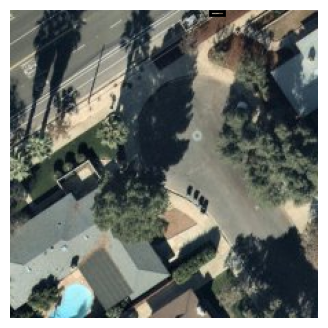

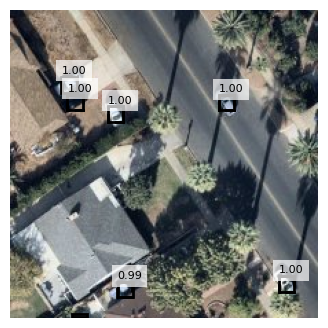

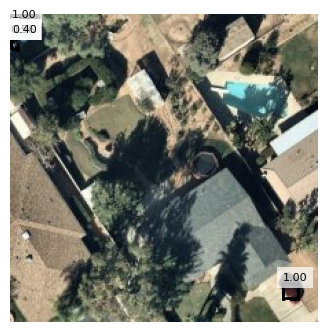

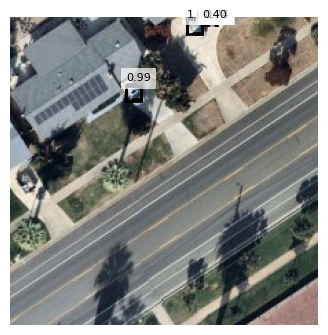

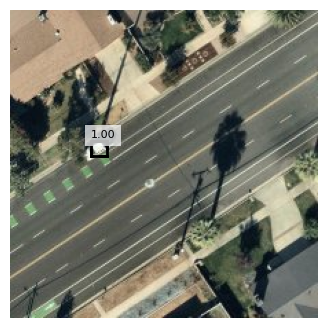

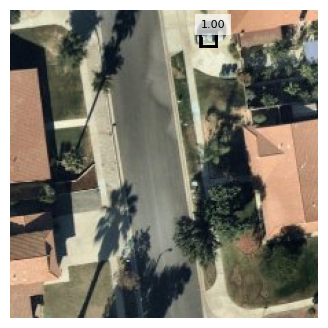

In [12]:
ckpt = torch.load(best_path, map_location="cpu")
model.load_state_dict(ckpt["model"])
model.to(device)
model.eval()

@torch.no_grad()
def show_predictions(subset, k=6, score_thr=0.4):
    idxs = random.sample(range(len(subset)), min(k, len(subset)))
    for si in idxs:
        img, target = subset[si]
        x = img.to(device)
        out = model([x])[0]

        im = (img.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

        fig, ax = plt.subplots(figsize=(4, 4))
        ax.imshow(im)

        gt = target["boxes"].cpu().numpy()
        for b in gt:
            x1, y1, x2, y2 = b
            ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2))

        scores = out["scores"].detach().cpu().numpy()
        boxes = out["boxes"].detach().cpu().numpy()
        keep = scores >= score_thr
        for b, s in zip(boxes[keep], scores[keep]):
            x1, y1, x2, y2 = b
            ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2, linestyle="--"))
            ax.text(x1, max(0, y1 - 2), f"{s:.2f}", fontsize=8, bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

        ax.axis("off")
        plt.show()

show_predictions(val_ds, k=6, score_thr=0.4)

In [13]:
torch.save(model.state_dict(), "fasterrcnn_cars_last_cpu_or_cuda.pt")